# TwoFluidPipe: One-Phase, Two-Phase, and Three-Phase Flow

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/equinor/neqsim/blob/master/examples/notebooks/TwoFluidPipe_1phase_2phase_3phase.ipynb)

Comprehensive guide to NeqSim's **TwoFluidPipe** model showing:

1. **One-phase flow** (gas, oil, water) — steady-state and transient
2. **Two-phase flow** (gas-liquid) — horizontal, inclined, riser
3. **Three-phase flow** (gas-oil-water) — with water cut tracking
4. **Boundary conditions** — how to set and change inlet/outlet conditions
5. **Transient dynamics** — ramp-up, shut-in, blowdown
6. **Slug tracking** — Lagrangian slug detection and statistics

## Model Equations

The TwoFluidPipe solves separate conservation equations for gas and liquid phases:

$$\frac{\partial}{\partial t}(\alpha_k \rho_k) + \frac{\partial}{\partial x}(\alpha_k \rho_k u_k) = \Gamma_k$$

$$\frac{\partial}{\partial t}(\alpha_k \rho_k u_k) + \frac{\partial}{\partial x}(\alpha_k \rho_k u_k^2 + \alpha_k P) = -\tau_{wk} \frac{S_{wk}}{A} \pm \tau_i \frac{S_i}{A} - \alpha_k \rho_k g \sin\theta$$

where $k = g, L$ for gas and liquid phases, $\alpha_k$ is holdup, and $\Gamma_k$ is mass transfer.

In [1]:
# Setup: works both locally (devtools) and via pip
import importlib, subprocess, sys

try:
    from neqsim_dev_setup import neqsim_init, neqsim_classes
    ns = neqsim_init(recompile=False)
    ns = neqsim_classes(ns)
    NEQSIM_MODE = "devtools"
    print("NeqSim loaded via devtools (local dev mode)")
except ImportError:
    try:
        import neqsim
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim"])
    from neqsim import jneqsim
    NEQSIM_MODE = "pip"
    print("NeqSim loaded via pip package")

Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim\target\neqsim-3.7.0.jar

JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes
All NeqSim classes imported OK
NeqSim loaded via devtools (local dev mode)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import jpype

if NEQSIM_MODE == "devtools":
    SystemSrkEos = ns.SystemSrkEos
    Stream = ns.Stream
    ProcessSystem = ns.ProcessSystem
    TwoFluidPipe = ns.JClass("neqsim.process.equipment.pipeline.TwoFluidPipe")
    PipeBeggsAndBrills = ns.JClass("neqsim.process.equipment.pipeline.PipeBeggsAndBrills")
    UUID = ns.JClass("java.util.UUID")
else:
    SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
    Stream = jneqsim.process.equipment.stream.Stream
    ProcessSystem = jneqsim.process.processmodel.ProcessSystem
    TwoFluidPipe = jpype.JClass("neqsim.process.equipment.pipeline.TwoFluidPipe")
    PipeBeggsAndBrills = jpype.JClass("neqsim.process.equipment.pipeline.PipeBeggsAndBrills")
    UUID = jpype.JClass("java.util.UUID")

# Enums
BoundaryCondition = TwoFluidPipe.BoundaryCondition
SlugTrackingMode = TwoFluidPipe.SlugTrackingMode

print("All classes imported")

All classes imported


---
## 1. One-Phase Flow (Steady-State)

Single-phase gas through a 10 km horizontal pipeline. The TwoFluidPipe reduces to standard Darcy-Weisbach friction for single-phase flow.

In [3]:
# === 1. SINGLE-PHASE GAS: 10 km, 200 mm, 50 bara ===
fluid_gas = SystemSrkEos(273.15 + 25.0, 50.0)
fluid_gas.addComponent("methane", 0.90)
fluid_gas.addComponent("ethane", 0.07)
fluid_gas.addComponent("propane", 0.03)
fluid_gas.setMixingRule("classic")

inlet_gas = Stream("Gas Feed", fluid_gas)
inlet_gas.setFlowRate(25000.0, "kg/hr")
inlet_gas.run()

n_sec = 50
pipe_gas = TwoFluidPipe("Gas Pipeline", inlet_gas)
pipe_gas.setLength(10000.0)      # 10 km
pipe_gas.setDiameter(0.2)        # 200 mm
pipe_gas.setRoughness(4.6e-5)    # Steel roughness
pipe_gas.setNumberOfSections(n_sec)
pipe_gas.setElevationProfile([0.0] * n_sec)  # horizontal

proc = ProcessSystem()
proc.add(inlet_gas)
proc.add(pipe_gas)
proc.run()

# Extract profiles
P_gas = np.array(pipe_gas.getPressureProfile()) / 1e5  # Pa -> bar
T_gas = np.array(pipe_gas.getTemperatureProfile()) - 273.15  # K -> C
x_gas = np.linspace(0, 10, len(P_gas))  # km

dp_gas = P_gas[0] - P_gas[-1]
print(f"Single-phase gas: dP = {dp_gas:.2f} bar over 10 km ({dp_gas/10:.3f} bar/km)")
print(f"Inlet P = {P_gas[0]:.2f} bar, Outlet P = {P_gas[-1]:.2f} bar")

# Cross-validate with Beggs-Brill
inlet_bb = Stream("BB Feed", fluid_gas)
inlet_bb.setFlowRate(25000.0, "kg/hr")
inlet_bb.run()
pipe_bb = PipeBeggsAndBrills("BB Ref", inlet_bb)
pipe_bb.setLength(10000.0)
pipe_bb.setDiameter(0.2)
pipe_bb.setPipeWallRoughness(4.6e-5)
pipe_bb.setAngle(0)
pipe_bb.setNumberOfIncrements(50)
pipe_bb.run()
dp_bb = float(inlet_bb.getPressure("bara")) - float(pipe_bb.getOutletStream().getPressure("bara"))
print(f"Beggs-Brill dP = {dp_bb:.2f} bar, TF/BB ratio = {dp_gas/dp_bb:.3f}")

Single-phase gas: dP = 4.26 bar over 10 km (0.426 bar/km)
Inlet P = 50.00 bar, Outlet P = 45.74 bar
Beggs-Brill dP = 4.58 bar, TF/BB ratio = 0.932


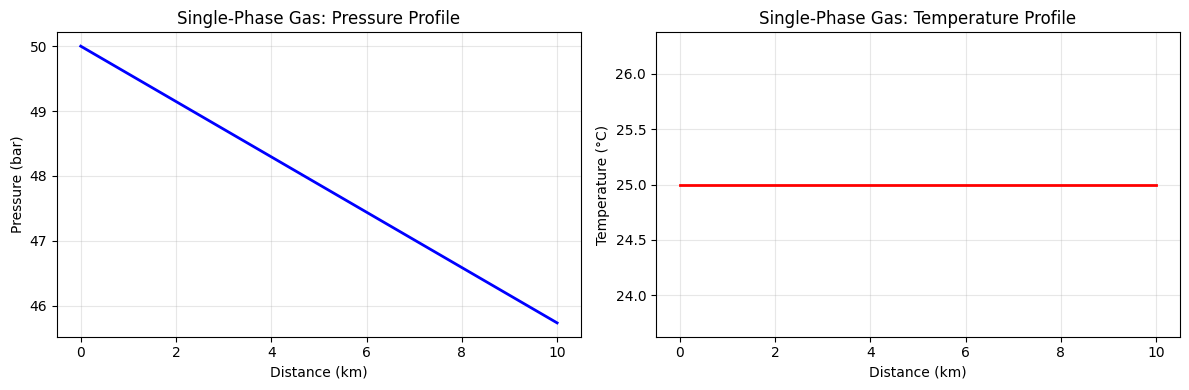

In [4]:
# Plot single-phase results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(x_gas, P_gas, 'b-', linewidth=2)
ax1.set_xlabel("Distance (km)")
ax1.set_ylabel("Pressure (bar)")
ax1.set_title("Single-Phase Gas: Pressure Profile")
ax1.grid(True, alpha=0.3)

ax2.plot(x_gas, T_gas, 'r-', linewidth=2)
ax2.set_xlabel("Distance (km)")
ax2.set_ylabel("Temperature (°C)")
ax2.set_title("Single-Phase Gas: Temperature Profile")
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

---
## 2. Two-Phase Flow (Gas-Liquid) — Steady-State

Gas-condensate through a 15 km horizontal pipeline. The two-fluid model tracks separate gas and liquid phases with slip between them.

In [5]:
# === 2. TWO-PHASE GAS-LIQUID: 15 km, 250 mm, 70 bara ===
fluid_2p = SystemSrkEos(273.15 + 40.0, 70.0)
fluid_2p.addComponent("methane", 0.75)
fluid_2p.addComponent("ethane", 0.05)
fluid_2p.addComponent("propane", 0.05)
fluid_2p.addComponent("n-pentane", 0.08)
fluid_2p.addComponent("n-heptane", 0.07)
fluid_2p.setMixingRule("classic")
fluid_2p.setMultiPhaseCheck(True)

inlet_2p = Stream("Two-Phase Feed", fluid_2p)
inlet_2p.setFlowRate(30000.0, "kg/hr")
inlet_2p.run()

n_sec = 60
pipe_2p = TwoFluidPipe("Two-Phase Pipeline", inlet_2p)
pipe_2p.setLength(15000.0)
pipe_2p.setDiameter(0.254)       # 10 inch
pipe_2p.setRoughness(4.6e-5)
pipe_2p.setNumberOfSections(n_sec)
pipe_2p.setElevationProfile([0.0] * n_sec)

proc2 = ProcessSystem()
proc2.add(inlet_2p)
proc2.add(pipe_2p)
proc2.run()

# Extract profiles
P_2p = np.array(pipe_2p.getPressureProfile()) / 1e5
HL_2p = np.array(pipe_2p.getLiquidHoldupProfile())
vG_2p = np.array(pipe_2p.getGasVelocityProfile())
vL_2p = np.array(pipe_2p.getLiquidVelocityProfile())
x_2p = np.linspace(0, 15, len(P_2p))

dp_2p = P_2p[0] - P_2p[-1]
print(f"Two-phase flow: dP = {dp_2p:.2f} bar over 15 km ({dp_2p/15:.3f} bar/km)")
print(f"Average liquid holdup = {np.mean(HL_2p):.4f}")
print(f"Liquid inventory = {float(pipe_2p.getLiquidInventory('m3')):.2f} m3")
print(f"\nFlow analysis:\n{pipe_2p.getFlowAnalysisSummary()}")

Two-phase flow: dP = 1.59 bar over 15 km (0.106 bar/km)
Average liquid holdup = 0.2855
Liquid inventory = 217.02 m3

Flow analysis:
=== Two-Phase Flow Analysis (Mid-Pipe) ===
Flow regime: STRATIFIED_WAVY

--- Velocities ---
Superficial gas velocity (v_SG): 1.442 m/s
Superficial liquid velocity (v_SL): 0.142 m/s
Mixture velocity: 1.584 m/s
Actual gas velocity: 2.073 m/s
Actual liquid velocity: 0.466 m/s

--- Holdup ---
No-slip holdup (λ_L): 0.0895
Actual liquid holdup (H_L): 0.3041
Slip ratio (v_G/v_L): 4.445

--- Dimensionless Parameters (Literature Comparison) ---
Froude number (Fr): 1.007
Weber number (We): 10624.5
Liquid Reynolds (Re_SL): 25121
Gas Reynolds (Re_SG): 1621744

--- Properties ---
Gas density: 59.05 kg/m³
Liquid density: 960.72 kg/m³
Mixture density: 333.28 kg/m³
Surface tension: 0.0200 N/m



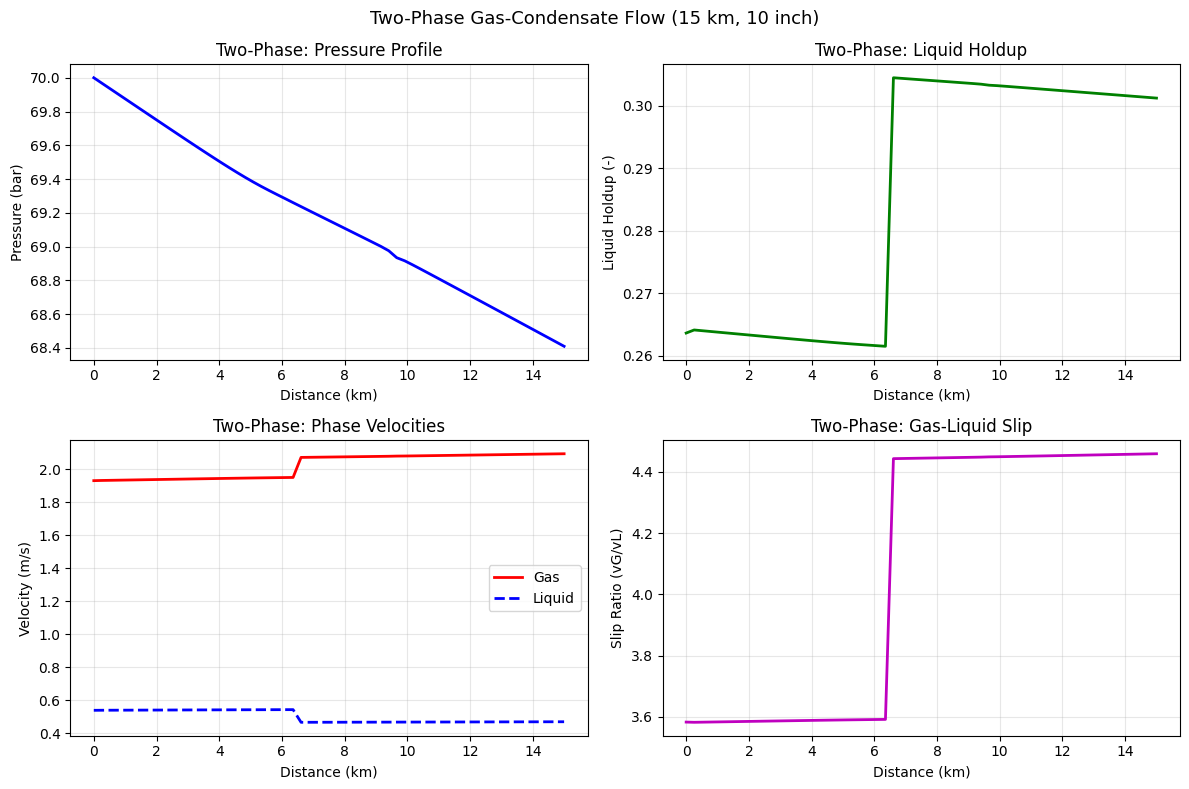

In [6]:
# Plot two-phase profiles
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(x_2p, P_2p, 'b-', linewidth=2)
axes[0, 0].set_xlabel("Distance (km)")
axes[0, 0].set_ylabel("Pressure (bar)")
axes[0, 0].set_title("Two-Phase: Pressure Profile")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(x_2p, HL_2p, 'g-', linewidth=2)
axes[0, 1].set_xlabel("Distance (km)")
axes[0, 1].set_ylabel("Liquid Holdup (-)")
axes[0, 1].set_title("Two-Phase: Liquid Holdup")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(x_2p, vG_2p, 'r-', linewidth=2, label='Gas')
axes[1, 0].plot(x_2p, vL_2p, 'b--', linewidth=2, label='Liquid')
axes[1, 0].set_xlabel("Distance (km)")
axes[1, 0].set_ylabel("Velocity (m/s)")
axes[1, 0].set_title("Two-Phase: Phase Velocities")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Slip ratio
slip = np.array(vG_2p) / np.maximum(np.array(vL_2p), 0.001)
axes[1, 1].plot(x_2p, slip, 'm-', linewidth=2)
axes[1, 1].set_xlabel("Distance (km)")
axes[1, 1].set_ylabel("Slip Ratio (vG/vL)")
axes[1, 1].set_title("Two-Phase: Gas-Liquid Slip")
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle("Two-Phase Gas-Condensate Flow (15 km, 10 inch)", fontsize=13)
fig.tight_layout()
plt.show()

---
## 3. Three-Phase Flow (Gas-Oil-Water) — Steady-State

Three-phase flow with 15% water cut. The TwoFluidPipe tracks gas, oil, and water phases separately, computing water holdup and oil-water slip.

In [7]:
# === 3. THREE-PHASE GAS-OIL-WATER: 10 km, 200 mm, 50 bara ===
fluid_3p = SystemSrkEos(273.15 + 50.0, 50.0)
fluid_3p.addComponent("methane", 0.55)
fluid_3p.addComponent("ethane", 0.05)
fluid_3p.addComponent("n-pentane", 0.10)
fluid_3p.addComponent("n-heptane", 0.10)
fluid_3p.addComponent("nC10", 0.05)
fluid_3p.addComponent("water", 0.15)
fluid_3p.setMixingRule("classic")
fluid_3p.setMultiPhaseCheck(True)

inlet_3p = Stream("Three-Phase Feed", fluid_3p)
inlet_3p.setFlowRate(25000.0, "kg/hr")
inlet_3p.run()

n_sec = 40
pipe_3p = TwoFluidPipe("Three-Phase Pipeline", inlet_3p)
pipe_3p.setLength(10000.0)
pipe_3p.setDiameter(0.203)      # 8 inch
pipe_3p.setRoughness(4.6e-5)
pipe_3p.setNumberOfSections(n_sec)
pipe_3p.setElevationProfile([0.0] * n_sec)

proc3 = ProcessSystem()
proc3.add(inlet_3p)
proc3.add(pipe_3p)
proc3.run()

# Extract three-phase profiles
P_3p = np.array(pipe_3p.getPressureProfile()) / 1e5
HL_3p = np.array(pipe_3p.getLiquidHoldupProfile())
WC_3p = np.array(pipe_3p.getWaterCutProfile())
WH_3p = np.array(pipe_3p.getWaterHoldupProfile())
OH_3p = np.array(pipe_3p.getOilHoldupProfile())
x_3p = np.linspace(0, 10, len(P_3p))

dp_3p = P_3p[0] - P_3p[-1]
out_flow = float(pipe_3p.getOutletStream().getFlowRate("kg/hr"))
mb_err = abs(out_flow - 25000.0) / 25000.0 * 100

print(f"Three-phase flow: dP = {dp_3p:.2f} bar over 10 km")
print(f"Average liquid holdup = {np.mean(HL_3p):.4f}")
print(f"Average water cut = {np.mean(WC_3p):.4f}")
print(f"Mass balance error = {mb_err:.2f}%")

Three-phase flow: dP = 2.55 bar over 10 km
Average liquid holdup = 0.2853
Average water cut = 0.4125
Mass balance error = 0.00%


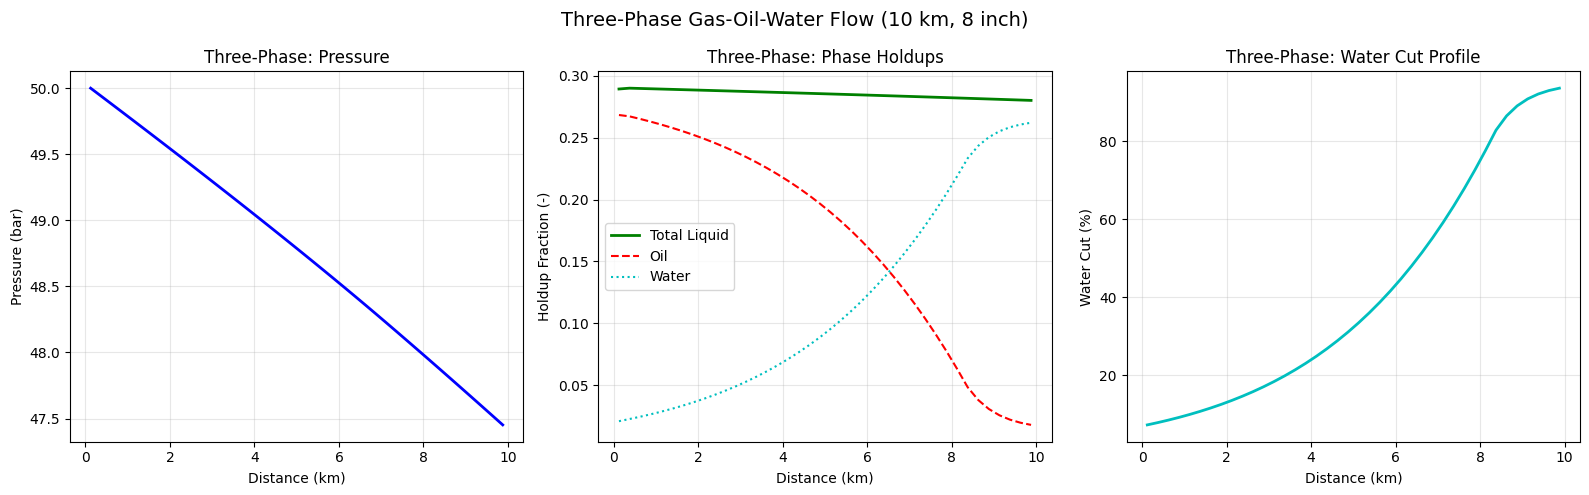

In [8]:
# Plot three-phase profiles
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Three-Phase Gas-Oil-Water Flow (10 km, 8 inch)', fontsize=14)

x_3p = np.array(list(pipe_3p.getPositionProfile())) / 1000
P_3p = np.array(list(pipe_3p.getPressureProfile())) / 1e5
HL_3p = np.array(list(pipe_3p.getLiquidHoldupProfile()))
OH_3p = np.array(list(pipe_3p.getOilHoldupProfile()))
WH_3p = np.array(list(pipe_3p.getWaterHoldupProfile()))
WC_3p = np.array(list(pipe_3p.getWaterCutProfile())) * 100

axes[0].plot(x_3p, P_3p, 'b-', linewidth=2)
axes[0].set_xlabel('Distance (km)'); axes[0].set_ylabel('Pressure (bar)')
axes[0].set_title('Three-Phase: Pressure'); axes[0].grid(True, alpha=0.3)

axes[1].plot(x_3p, HL_3p, 'g-', linewidth=2, label='Total Liquid')
axes[1].plot(x_3p, OH_3p, 'r--', linewidth=1.5, label='Oil')
axes[1].plot(x_3p, WH_3p, 'c:', linewidth=1.5, label='Water')
axes[1].set_xlabel('Distance (km)'); axes[1].set_ylabel('Holdup Fraction (-)')
axes[1].set_title('Three-Phase: Phase Holdups'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(x_3p, WC_3p, 'c-', linewidth=2)
axes[2].set_xlabel('Distance (km)'); axes[2].set_ylabel('Water Cut (%)')
axes[2].set_title('Three-Phase: Water Cut Profile'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('three_phase_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Boundary Conditions — How to Set and Change Them

The TwoFluidPipe supports 5 boundary condition types:

| Type | Description | Use Case |
|------|-------------|----------|
| `STREAM_CONNECTED` | Properties from inlet stream (default inlet) | Normal operation |
| `CONSTANT_FLOW` | Fixed mass flow rate | Known well rate |
| `CONSTANT_PRESSURE` | Fixed pressure (default outlet) | Known receiving pressure |
| `CLOSED` | No flow, pressure floats | Shut-in, blowdown |
| `CHARACTERISTIC` | Riemann invariant-based | Reduces wave reflections |

### Default Configuration
- **Inlet**: `STREAM_CONNECTED` — flow rate from the connected stream
- **Outlet**: `CONSTANT_PRESSURE` — fixed at outlet pressure

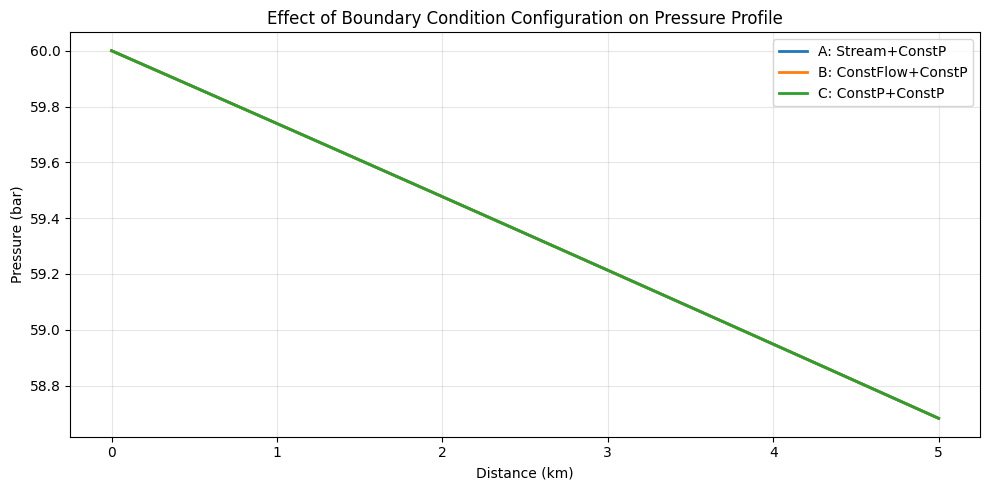

A: Stream+ConstP: Inlet=60.00 bar, Outlet=58.68 bar, dP=1.32 bar
B: ConstFlow+ConstP: Inlet=60.00 bar, Outlet=58.68 bar, dP=1.32 bar
C: ConstP+ConstP: Inlet=60.00 bar, Outlet=58.68 bar, dP=1.32 bar


In [9]:
# === 4. BOUNDARY CONDITIONS DEMONSTRATION ===
# Use two-phase fluid, show 3 different BC configurations

fluid_bc = SystemSrkEos(273.15 + 40.0, 60.0)
fluid_bc.addComponent("methane", 0.85)
fluid_bc.addComponent("n-pentane", 0.10)
fluid_bc.addComponent("n-heptane", 0.05)
fluid_bc.setMixingRule("classic")
fluid_bc.setMultiPhaseCheck(True)

results_bc = {}

# --- Config A: STREAM_CONNECTED inlet, CONSTANT_PRESSURE outlet (default) ---
inlet_a = Stream("Feed A", fluid_bc)
inlet_a.setFlowRate(20000.0, "kg/hr")
inlet_a.run()

pipe_a = TwoFluidPipe("Config-A", inlet_a)
pipe_a.setLength(5000.0)
pipe_a.setDiameter(0.203)
pipe_a.setRoughness(4.6e-5)
pipe_a.setNumberOfSections(30)
pipe_a.setElevationProfile([0.0] * 30)
# Defaults: inlet=STREAM_CONNECTED, outlet=CONSTANT_PRESSURE

proc_a = ProcessSystem()
proc_a.add(inlet_a)
proc_a.add(pipe_a)
proc_a.run()
results_bc['A: Stream+ConstP'] = np.array(pipe_a.getPressureProfile()) / 1e5

# --- Config B: CONSTANT_FLOW inlet, CONSTANT_PRESSURE outlet ---
inlet_b = Stream("Feed B", fluid_bc)
inlet_b.setFlowRate(20000.0, "kg/hr")
inlet_b.run()

pipe_b = TwoFluidPipe("Config-B", inlet_b)
pipe_b.setLength(5000.0)
pipe_b.setDiameter(0.203)
pipe_b.setRoughness(4.6e-5)
pipe_b.setNumberOfSections(30)
pipe_b.setElevationProfile([0.0] * 30)
pipe_b.setInletBoundaryCondition(BoundaryCondition.CONSTANT_FLOW)
pipe_b.setInletMassFlow(20000.0 / 3600.0)  # kg/s
pipe_b.setOutletPressure(55.0, "bara")

proc_b = ProcessSystem()
proc_b.add(inlet_b)
proc_b.add(pipe_b)
proc_b.run()
results_bc['B: ConstFlow+ConstP'] = np.array(pipe_b.getPressureProfile()) / 1e5

# --- Config C: CONSTANT_PRESSURE at both ends ---
inlet_c = Stream("Feed C", fluid_bc)
inlet_c.setFlowRate(20000.0, "kg/hr")
inlet_c.run()

pipe_c = TwoFluidPipe("Config-C", inlet_c)
pipe_c.setLength(5000.0)
pipe_c.setDiameter(0.203)
pipe_c.setRoughness(4.6e-5)
pipe_c.setNumberOfSections(30)
pipe_c.setElevationProfile([0.0] * 30)
pipe_c.setInletBoundaryCondition(BoundaryCondition.CONSTANT_PRESSURE)
pipe_c.setInletPressure(60.0, "bara")
pipe_c.setOutletPressure(55.0, "bara")

proc_c = ProcessSystem()
proc_c.add(inlet_c)
proc_c.add(pipe_c)
proc_c.run()
results_bc['C: ConstP+ConstP'] = np.array(pipe_c.getPressureProfile()) / 1e5

# Compare
fig, ax = plt.subplots(figsize=(10, 5))
x_bc = np.linspace(0, 5, len(results_bc['A: Stream+ConstP']))
for label, P in results_bc.items():
    ax.plot(x_bc, P, linewidth=2, label=label)

ax.set_xlabel("Distance (km)")
ax.set_ylabel("Pressure (bar)")
ax.set_title("Effect of Boundary Condition Configuration on Pressure Profile")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for label, P in results_bc.items():
    print(f"{label}: Inlet={P[0]:.2f} bar, Outlet={P[-1]:.2f} bar, dP={P[0]-P[-1]:.2f} bar")

---
## 5. Transient Simulation — Changing Conditions During a Run

This section demonstrates how to:
1. Initialize with steady-state (`pipe.run()`)
2. Run transient time steps (`pipe.runTransient(dt, uuid)`)
3. **Change inlet flow rate** during the transient
4. **Shut in the outlet** (close outlet valve)
5. **Reopen** the outlet with a new pressure

The key pattern is:
```python
pipe.run()                            # 1. Steady-state initialization
for t in range(n_steps):
    pipe.runTransient(dt, run_id)     # 2. Advance one time step
    # 3. Change conditions at any point:
    pipe.setInletMassFlow(new_flow)   #    - change flow rate
    pipe.closeOutlet()                #    - shut in
    pipe.openOutlet(30.0, "bara")     #    - reopen
```

In [10]:
# === 5. TRANSIENT: Ramp-up, shut-in, reopen ===
fluid_tr = SystemSrkEos(273.15 + 40.0, 60.0)
fluid_tr.addComponent("methane", 0.80)
fluid_tr.addComponent("n-pentane", 0.12)
fluid_tr.addComponent("n-heptane", 0.08)
fluid_tr.setMixingRule("classic")
fluid_tr.setMultiPhaseCheck(True)

inlet_tr = Stream("Transient Feed", fluid_tr)
inlet_tr.setFlowRate(15000.0, "kg/hr")
inlet_tr.run()

n_sec = 15
pipe_tr = TwoFluidPipe("Transient Pipe", inlet_tr)
pipe_tr.setLength(500.0)       # 500 m (short for fast transient)
pipe_tr.setDiameter(0.203)
pipe_tr.setRoughness(4.6e-5)
pipe_tr.setNumberOfSections(n_sec)
pipe_tr.setElevationProfile([0.0] * n_sec)

# Use CONSTANT_FLOW so we can change flow rate during transient
pipe_tr.setInletBoundaryCondition(BoundaryCondition.CONSTANT_FLOW)
pipe_tr.setInletMassFlow(15000.0 / 3600.0)  # kg/s
pipe_tr.setOutletPressure(55.0, "bara")

proc_tr = ProcessSystem()
proc_tr.add(inlet_tr)
proc_tr.add(pipe_tr)
proc_tr.run()  # Steady-state initialization

print(f"Initial steady-state: dP = {(pipe_tr.getPressureProfile()[0]/1e5 - 55.0):.3f} bar")

# --- Transient loop: 3 phases ---
# Phase 1 (0-20s): Normal flow at 15 t/hr
# Phase 2 (20-40s): Ramp up to 30 t/hr
# Phase 3 (40-60s): Shut in outlet, then reopen at 50s

dt = 0.5  # seconds
n_total = 120  # 60 seconds total
run_id = UUID.randomUUID()

time_log = []
inlet_P_log = []
outlet_P_log = []
holdup_log = []
flow_log = []

for step in range(n_total):
    t = step * dt

    # Phase 1: Normal flow
    if t < 20.0:
        current_flow = 15000.0 / 3600.0  # kg/s
    # Phase 2: Ramp up
    elif t < 40.0:
        frac = (t - 20.0) / 20.0
        current_flow = (15000.0 + frac * 15000.0) / 3600.0
    # Phase 3: Shut-in at t=40, reopen at t=50
    elif t < 40.5:
        pipe_tr.closeOutlet()
        current_flow = 15000.0 / 3600.0
    elif t < 50.0:
        current_flow = 15000.0 / 3600.0  # still flowing into closed pipe
    elif t < 50.5:
        pipe_tr.openOutlet(55.0, "bara")
        current_flow = 15000.0 / 3600.0
    else:
        current_flow = 15000.0 / 3600.0

    if not pipe_tr.isOutletClosed():
        pipe_tr.setInletMassFlow(current_flow)

    pipe_tr.runTransient(dt, run_id)

    P_profile = pipe_tr.getPressureProfile()
    HL_profile = pipe_tr.getLiquidHoldupProfile()

    time_log.append(t)
    inlet_P_log.append(P_profile[0] / 1e5)
    outlet_P_log.append(P_profile[-1] / 1e5)
    holdup_log.append(np.mean(np.array(HL_profile)))
    flow_log.append(current_flow * 3600 / 1000)  # t/hr

print(f"Transient completed: {n_total} steps x {dt}s = {n_total*dt:.0f}s")

Initial steady-state: dP = 5.000 bar
Transient completed: 120 steps x 0.5s = 60s


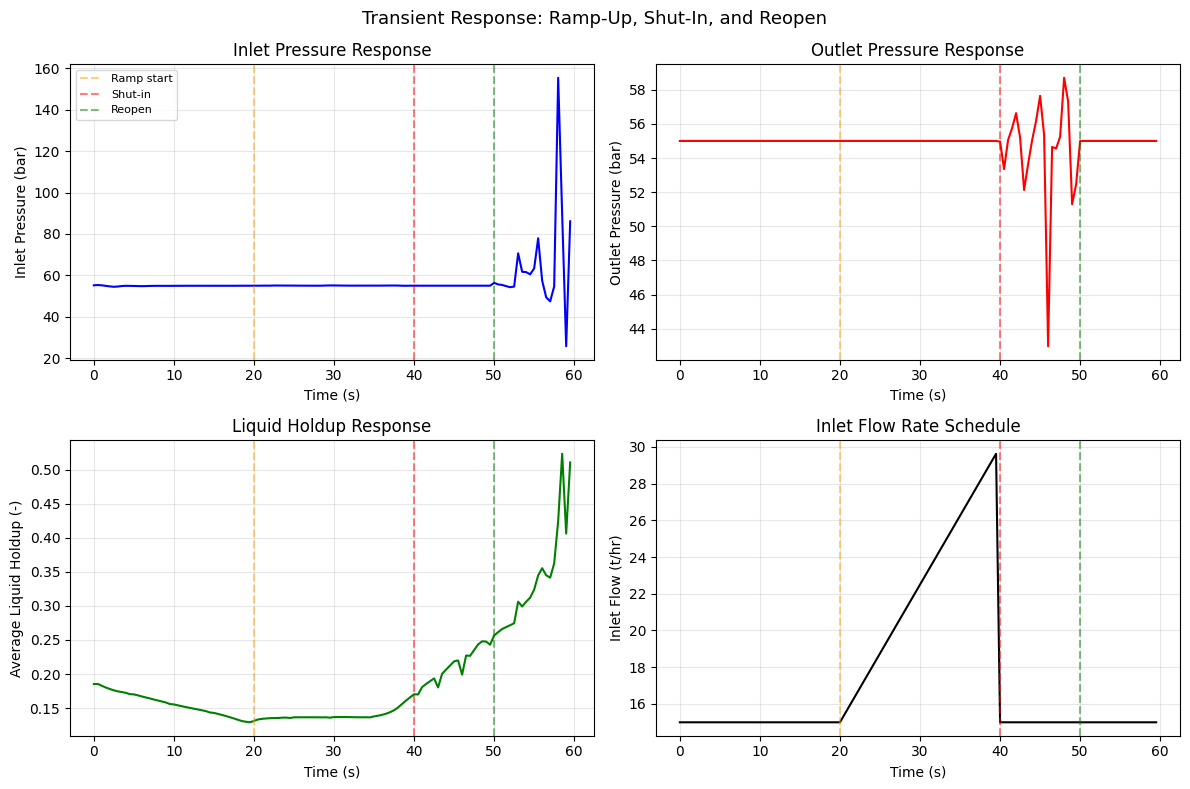

In [11]:
# Plot transient response
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
t_arr = np.array(time_log)

# Inlet pressure
axes[0, 0].plot(t_arr, inlet_P_log, 'b-', linewidth=1.5)
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Inlet Pressure (bar)")
axes[0, 0].set_title("Inlet Pressure Response")
axes[0, 0].axvline(x=20, color='orange', linestyle='--', alpha=0.5, label='Ramp start')
axes[0, 0].axvline(x=40, color='red', linestyle='--', alpha=0.5, label='Shut-in')
axes[0, 0].axvline(x=50, color='green', linestyle='--', alpha=0.5, label='Reopen')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Outlet pressure
axes[0, 1].plot(t_arr, outlet_P_log, 'r-', linewidth=1.5)
axes[0, 1].set_xlabel("Time (s)")
axes[0, 1].set_ylabel("Outlet Pressure (bar)")
axes[0, 1].set_title("Outlet Pressure Response")
axes[0, 1].axvline(x=20, color='orange', linestyle='--', alpha=0.5)
axes[0, 1].axvline(x=40, color='red', linestyle='--', alpha=0.5)
axes[0, 1].axvline(x=50, color='green', linestyle='--', alpha=0.5)
axes[0, 1].grid(True, alpha=0.3)

# Average holdup
axes[1, 0].plot(t_arr, holdup_log, 'g-', linewidth=1.5)
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Average Liquid Holdup (-)")
axes[1, 0].set_title("Liquid Holdup Response")
axes[1, 0].axvline(x=20, color='orange', linestyle='--', alpha=0.5)
axes[1, 0].axvline(x=40, color='red', linestyle='--', alpha=0.5)
axes[1, 0].axvline(x=50, color='green', linestyle='--', alpha=0.5)
axes[1, 0].grid(True, alpha=0.3)

# Flow rate
axes[1, 1].plot(t_arr, flow_log, 'k-', linewidth=1.5)
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].set_ylabel("Inlet Flow (t/hr)")
axes[1, 1].set_title("Inlet Flow Rate Schedule")
axes[1, 1].axvline(x=20, color='orange', linestyle='--', alpha=0.5)
axes[1, 1].axvline(x=40, color='red', linestyle='--', alpha=0.5)
axes[1, 1].axvline(x=50, color='green', linestyle='--', alpha=0.5)
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle("Transient Response: Ramp-Up, Shut-In, and Reopen", fontsize=13)
fig.tight_layout()
plt.show()

---
## 6. Slug Tracking

The TwoFluidPipe supports two slug tracking modes:

| Mode | Description | Best For |
|------|-------------|----------|
| `LAGRANGIAN` | Full OLGA-style tracking of individual slugs | Terrain slugging, statistics |
| `SIMPLIFIED` | Simplified slug unit model | Quick screening |
| `DISABLED` | No slug tracking | When not needed |

### Key Methods:
- `setEnableSlugTracking(True)` — Enable tracking
- `setSlugTrackingMode(SlugTrackingMode.LAGRANGIAN)` — Set mode  
- `configureLagrangianSlugTracking(inlet, terrain, wake)` — Advanced config
- `getSlugStatisticsSummary()` — Human-readable summary
- `getSlugTrackingStatisticsJson()` — JSON statistics
- `getOutletSlugCount()` — Number of slugs at outlet

In [12]:
# --- Section 6: Slug Tracking with Terrain Undulations ---
#
# For terrain-induced slugging, we need:
#   1. TWO-PHASE flow with moderate liquid content
#   2. Gas Froude number < 1.5 at the low points (Froude = vSG / sqrt(g*D*(rhoL-rhoG)/rhoG))
#      This means LOW gas velocity so liquid can pool in valleys
#   3. Gentle terrain undulations that trap liquid
#
# If gas velocity is too high (Fr > 1.5): liquid is swept through → no slugs
# If gas velocity is too low / too much liquid: pipe floods → holdup → 0.95
# The sweet spot is in between: stratified flow with periodic slug release

slug_fluid = SystemSrkEos(273.15 + 30.0, 60.0)
slug_fluid.addComponent("methane", 0.75)
slug_fluid.addComponent("ethane", 0.10)
slug_fluid.addComponent("propane", 0.07)
slug_fluid.addComponent("n-butane", 0.04)
slug_fluid.addComponent("n-pentane", 0.025)
slug_fluid.addComponent("n-hexane", 0.015)
slug_fluid.setMixingRule("classic")
slug_fluid.setMultiPhaseCheck(True)

slug_feed = Stream("slug-feed", slug_fluid)
slug_feed.setFlowRate(8000.0, "kg/hr")    # Low flow → Fr ~ 0.14, liquid pools in valleys
slug_feed.setTemperature(30.0, "C")
slug_feed.setPressure(60.0, "bara")

# 10-inch pipe, 10 km, with gentle terrain undulations
n_sections = 200  # Finer grid for better mass conservation
slug_pipe = TwoFluidPipe("slug-pipe", slug_feed)
slug_pipe.setLength(10000.0)
slug_pipe.setDiameter(0.2540)            # 10 inch
slug_pipe.setOutletPressure(55.0, "bara")
slug_pipe.setRoughness(5e-5)
slug_pipe.setNumberOfSections(n_sections)

# Terrain: ±3m undulations every 2 km on a near-horizontal pipe
elevation = []
for i in range(n_sections):
    x = float(i) / (n_sections - 1) * 10000.0
    undulation = 3.0 * np.sin(2.0 * np.pi * x / 2000.0)
    elevation.append(undulation)
slug_pipe.setElevationProfile(elevation)

# Enable Lagrangian slug tracking
slug_pipe.setEnableSlugTracking(True)
slug_pipe.setSlugTrackingMode(SlugTrackingMode.LAGRANGIAN)
slug_pipe.configureLagrangianSlugTracking(True, True, True)

# Run steady-state to initialize
process_slug = ProcessSystem()
process_slug.add(slug_feed)
process_slug.add(slug_pipe)
process_slug.run()

# Check initial conditions
h_init = list(slug_pipe.getLiquidHoldupProfile())
print(f"Initial SS: avg holdup = {np.mean(h_init):.4f}, max = {np.max(h_init):.4f}")
print(f"\nFlow analysis at mid-pipe:")
print(slug_pipe.getFlowAnalysisSummary())

# Run transient (300s) with short timestep for better CFL compliance
print("\nRunning transient (300s, dt=0.25s, 200 sections)...")
slug_times = []
slug_outlet_p = []
slug_outlet_holdup = []
slug_counts = []

dt = 0.25   # Shorter timestep for better accuracy
n_steps = 1200  # 300 seconds total
run_id = UUID.randomUUID()
for step in range(n_steps):
    t = step * dt
    slug_pipe.runTransient(dt, run_id)
    slug_times.append(t)

    p_profile = list(slug_pipe.getPressureProfile())
    h_profile = list(slug_pipe.getLiquidHoldupProfile())
    slug_outlet_p.append(p_profile[-1] / 1e5 if p_profile else 0)
    slug_outlet_holdup.append(h_profile[-1] if h_profile else 0)
    slug_counts.append(slug_pipe.getOutletSlugCount())

# Print slug statistics
print("\n--- Slug Tracking Results ---")
print(f"  Outlet slug count: {slug_pipe.getOutletSlugCount()}")
max_slug = slug_pipe.getMaxSlugLengthAtOutlet()
print(f"  Max slug length: {max_slug:.1f} m")
print(f"\nSlug Statistics Summary:")
print(slug_pipe.getSlugStatisticsSummary())

# Final holdup profile — check valley/peak pattern
h_final = list(slug_pipe.getLiquidHoldupProfile())
pos_final = np.array(list(slug_pipe.getPositionProfile()))
print(f"\nFinal state: avg holdup = {np.mean(h_final):.4f}, max = {np.max(h_final):.4f}")

# Check holdup at terrain valleys vs peaks
print("\n--- Holdup at terrain features (expect: valleys HIGH, peaks LOW) ---")
valley_holdups = []
peak_holdups = []
for i_check in range(len(pos_final)):
    x_m = pos_final[i_check]
    elev_at = 3.0 * np.sin(2.0 * np.pi * x_m / 2000.0)
    if elev_at < -2.5:  # near valley bottom
        valley_holdups.append(h_final[i_check])
    elif elev_at > 2.5:  # near peak top
        peak_holdups.append(h_final[i_check])
if valley_holdups and peak_holdups:
    print(f"  Valley avg holdup: {np.mean(valley_holdups):.3f} (range {np.min(valley_holdups):.3f}-{np.max(valley_holdups):.3f})")
    print(f"  Peak avg holdup:   {np.mean(peak_holdups):.3f} (range {np.min(peak_holdups):.3f}-{np.max(peak_holdups):.3f})")
    print(f"  Valley/Peak ratio: {np.mean(valley_holdups)/np.mean(peak_holdups):.1f}x")
else:
    print("  (Not enough data points near valleys/peaks)")

Initial SS: avg holdup = 0.1697, max = 0.2886

Flow analysis at mid-pipe:
=== Two-Phase Flow Analysis (Mid-Pipe) ===
Flow regime: STRATIFIED_SMOOTH

--- Velocities ---
Superficial gas velocity (v_SG): 0.581 m/s
Superficial liquid velocity (v_SL): 0.017 m/s
Mixture velocity: 0.597 m/s
Actual gas velocity: 0.730 m/s
Actual liquid velocity: 0.081 m/s

--- Holdup ---
No-slip holdup (λ_L): 0.0280
Actual liquid holdup (H_L): 0.2050
Slip ratio (v_G/v_L): 8.963

--- Dimensionless Parameters (Literature Comparison) ---
Froude number (Fr): 0.143
Weber number (We): 1125.6
Liquid Reynolds (Re_SL): 3472
Gas Reynolds (Re_SG): 700835

--- Properties ---
Gas density: 61.15 kg/m³
Liquid density: 975.02 kg/m³
Mixture density: 248.48 kg/m³
Surface tension: 0.0200 N/m


Running transient (300s, dt=0.25s, 200 sections)...

--- Slug Tracking Results ---
  Outlet slug count: 1
  Max slug length: 0.0 m

Slug Statistics Summary:
=== Slug Statistics ===
Tracking mode: LAGRANGIAN
Active slugs in pipe: 0
Slugs ge

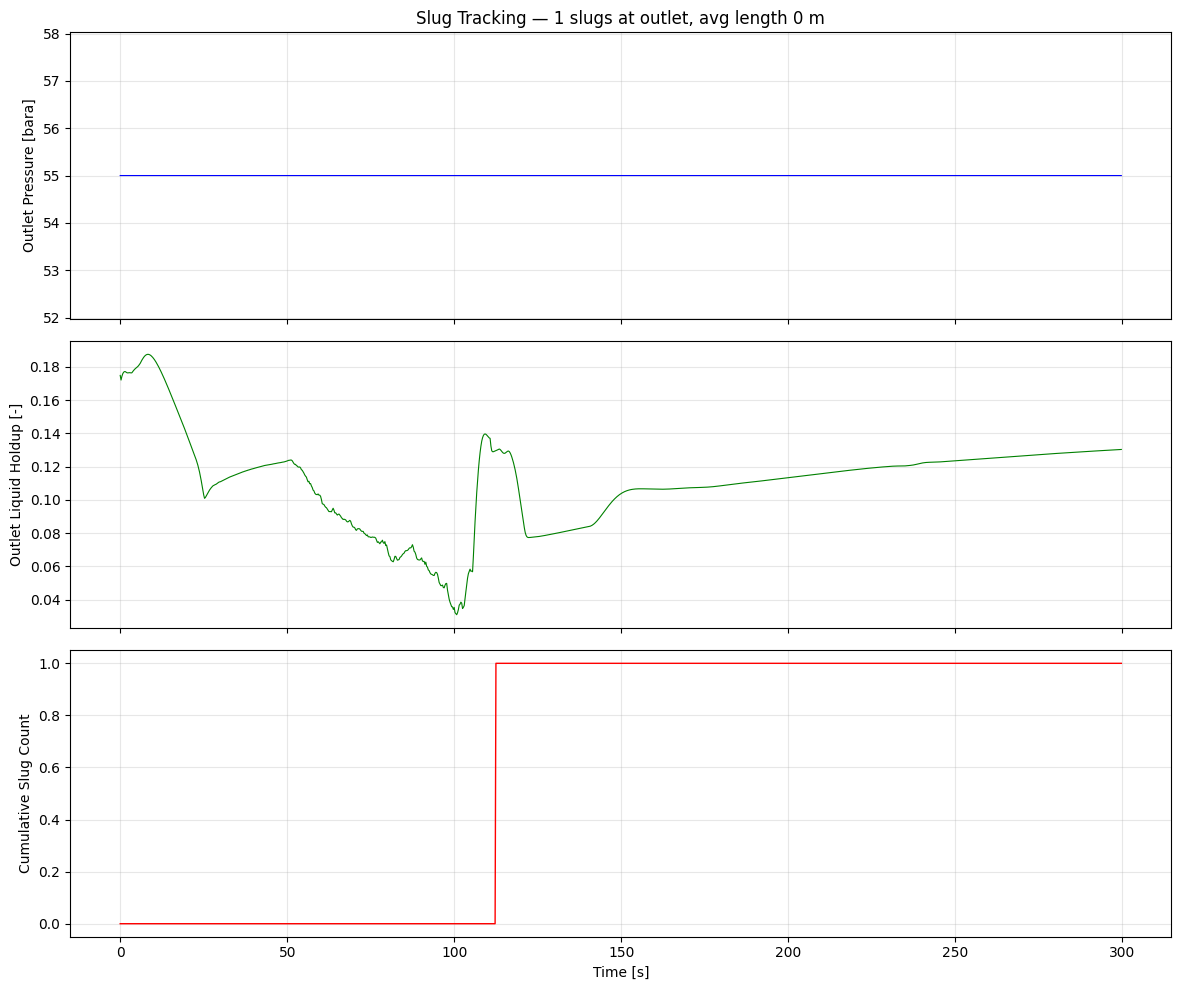

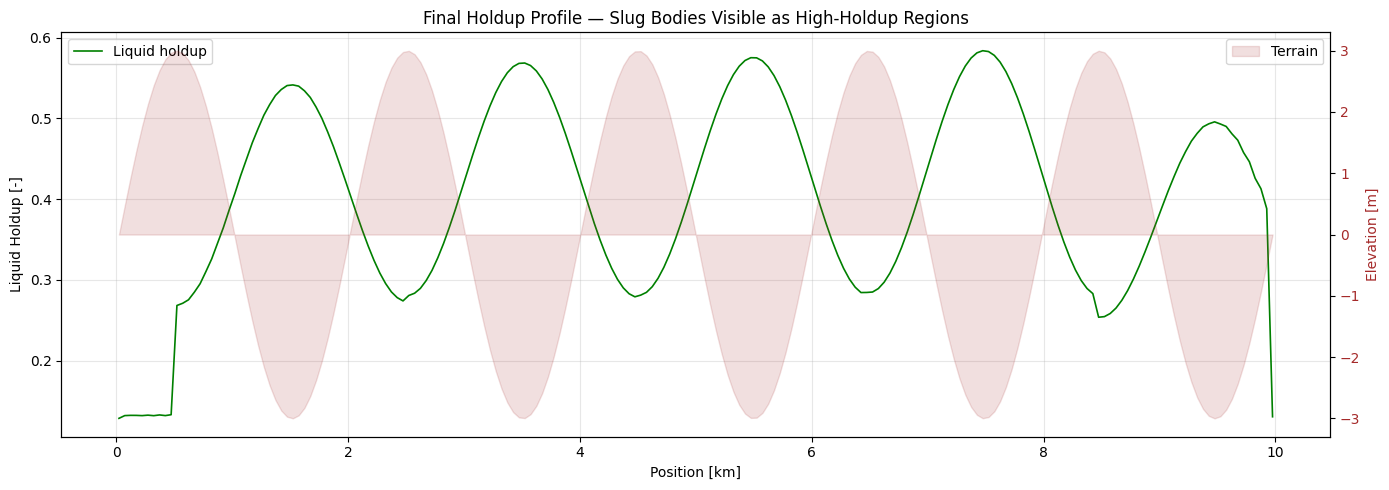

In [19]:
# Plot slug tracking results
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(slug_times, slug_outlet_p, 'b-', linewidth=0.8)
axes[0].set_ylabel('Outlet Pressure [bara]')
axes[0].set_title(f'Slug Tracking — {slug_pipe.getOutletSlugCount()} slugs at outlet, '
                   f'avg length {slug_pipe.getLagrangianSlugTracker().getAverageSlugLength():.0f} m')
axes[0].grid(True, alpha=0.3)

axes[1].plot(slug_times, slug_outlet_holdup, 'g-', linewidth=0.8)
axes[1].set_ylabel('Outlet Liquid Holdup [-]')
axes[1].grid(True, alpha=0.3)

axes[2].plot(slug_times, slug_counts, 'r-', linewidth=1.0)
axes[2].set_ylabel('Cumulative Slug Count')
axes[2].set_xlabel('Time [s]')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('slug_tracking_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Holdup profile along the pipe with terrain overlay
fig2, ax2 = plt.subplots(figsize=(14, 5))
pos = np.array(list(slug_pipe.getPositionProfile()))
holdup_final = np.array(list(slug_pipe.getLiquidHoldupProfile()))
elev_arr = np.array(elevation[:len(pos)])

ax_twin = ax2.twinx()
ax_twin.fill_between(pos / 1000, elev_arr, alpha=0.15, color='brown', label='Terrain')
ax_twin.set_ylabel('Elevation [m]', color='brown')
ax_twin.tick_params(axis='y', labelcolor='brown')

ax2.plot(pos / 1000, holdup_final, 'g-', linewidth=1.2, label='Liquid holdup')
ax2.set_xlabel('Position [km]')
ax2.set_ylabel('Liquid Holdup [-]')
ax2.set_title('Final Holdup Profile — Slug Bodies Visible as High-Holdup Regions')
ax2.legend(loc='upper left')
ax_twin.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('slug_holdup_profile.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Three-Phase Transient with Water Cut Change

This section demonstrates a transient three-phase simulation where the **water cut at the inlet changes** during operation — a common scenario when a new water-producing zone breaks through.

### Approach
We modify the inlet stream composition mid-simulation to increase the water fraction, then observe how the water holdup and water cut propagate through the pipeline.

In [14]:
# --- Section 7: Three-Phase Transient with Inlet Water Cut Change ---

# Create initial three-phase fluid (low water cut)
wc_fluid = SystemSrkEos(273.15 + 40.0, 60.0)
wc_fluid.addComponent("methane", 0.60)
wc_fluid.addComponent("ethane", 0.08)
wc_fluid.addComponent("propane", 0.05)
wc_fluid.addComponent("n-pentane", 0.04)
wc_fluid.addComponent("n-hexane", 0.03)
wc_fluid.addComponent("n-heptane", 0.05)
wc_fluid.addComponent("water", 0.15)  # 15% water initially
wc_fluid.setMixingRule("classic")
wc_fluid.setMultiPhaseCheck(True)

wc_feed = Stream("wc-feed", wc_fluid)
wc_feed.setFlowRate(40000.0, "kg/hr")
wc_feed.setTemperature(40.0, "C")
wc_feed.setPressure(60.0, "bara")

wc_pipe = TwoFluidPipe("wc-pipe", wc_feed)
wc_pipe.setLength(8000.0)          # 8 km
wc_pipe.setDiameter(0.2032)        # 8 inch
wc_pipe.setOutletPressure(45.0, "bara")
wc_pipe.setRoughness(5e-5)
wc_pipe.setNumberOfSections(50)

# Run steady-state
wc_process = ProcessSystem()
wc_process.add(wc_feed)
wc_process.add(wc_pipe)
wc_process.run()

print("Initial SS water cut profile (%):")
wc_init = list(wc_pipe.getWaterCutProfile())
print(f"  Inlet: {wc_init[0]*100:.1f}%  |  Outlet: {wc_init[-1]*100:.1f}%")

# Run transient: increase water cut at t=30s
print("\nRunning transient (60s total, water cut increase at t=30s)...")
wc_times = []
wc_outlet_wc = []
wc_outlet_holdup = []
wc_outlet_p = []

dt = 1.0
for step in range(60):
    t = step * dt

    # At t=30s, increase water fraction in inlet stream
    if step == 30:
        print(f"  t={t:.0f}s: Increasing inlet water cut (water mole frac 0.15 -> 0.35)")
        new_fluid = SystemSrkEos(273.15 + 40.0, 60.0)
        new_fluid.addComponent("methane", 0.48)
        new_fluid.addComponent("ethane", 0.06)
        new_fluid.addComponent("propane", 0.04)
        new_fluid.addComponent("n-pentane", 0.02)
        new_fluid.addComponent("n-hexane", 0.02)
        new_fluid.addComponent("n-heptane", 0.03)
        new_fluid.addComponent("water", 0.35)  # 35% water
        new_fluid.setMixingRule("classic")
        new_fluid.setMultiPhaseCheck(True)

        wc_feed.setFluid(new_fluid)
        wc_feed.setFlowRate(40000.0, "kg/hr")
        wc_feed.setTemperature(40.0, "C")
        wc_feed.setPressure(60.0, "bara")
        wc_feed.run()

    wc_pipe.runTransient(dt, UUID.randomUUID())

    wc_times.append(t)
    p_prof = list(wc_pipe.getPressureProfile())
    wc_prof = list(wc_pipe.getWaterCutProfile())
    h_prof = list(wc_pipe.getLiquidHoldupProfile())

    wc_outlet_p.append(p_prof[-1] / 1e5 if p_prof else 0)
    wc_outlet_wc.append(wc_prof[-1] * 100 if wc_prof else 0)
    wc_outlet_holdup.append(h_prof[-1] if h_prof else 0)

print(f"\nFinal outlet water cut: {wc_outlet_wc[-1]:.1f}%")
print(f"Final outlet holdup: {wc_outlet_holdup[-1]:.3f}")

Initial SS water cut profile (%):
  Inlet: 13.5%  |  Outlet: 94.7%

Running transient (60s total, water cut increase at t=30s)...
  t=30s: Increasing inlet water cut (water mole frac 0.15 -> 0.35)

Final outlet water cut: 94.2%
Final outlet holdup: 0.270


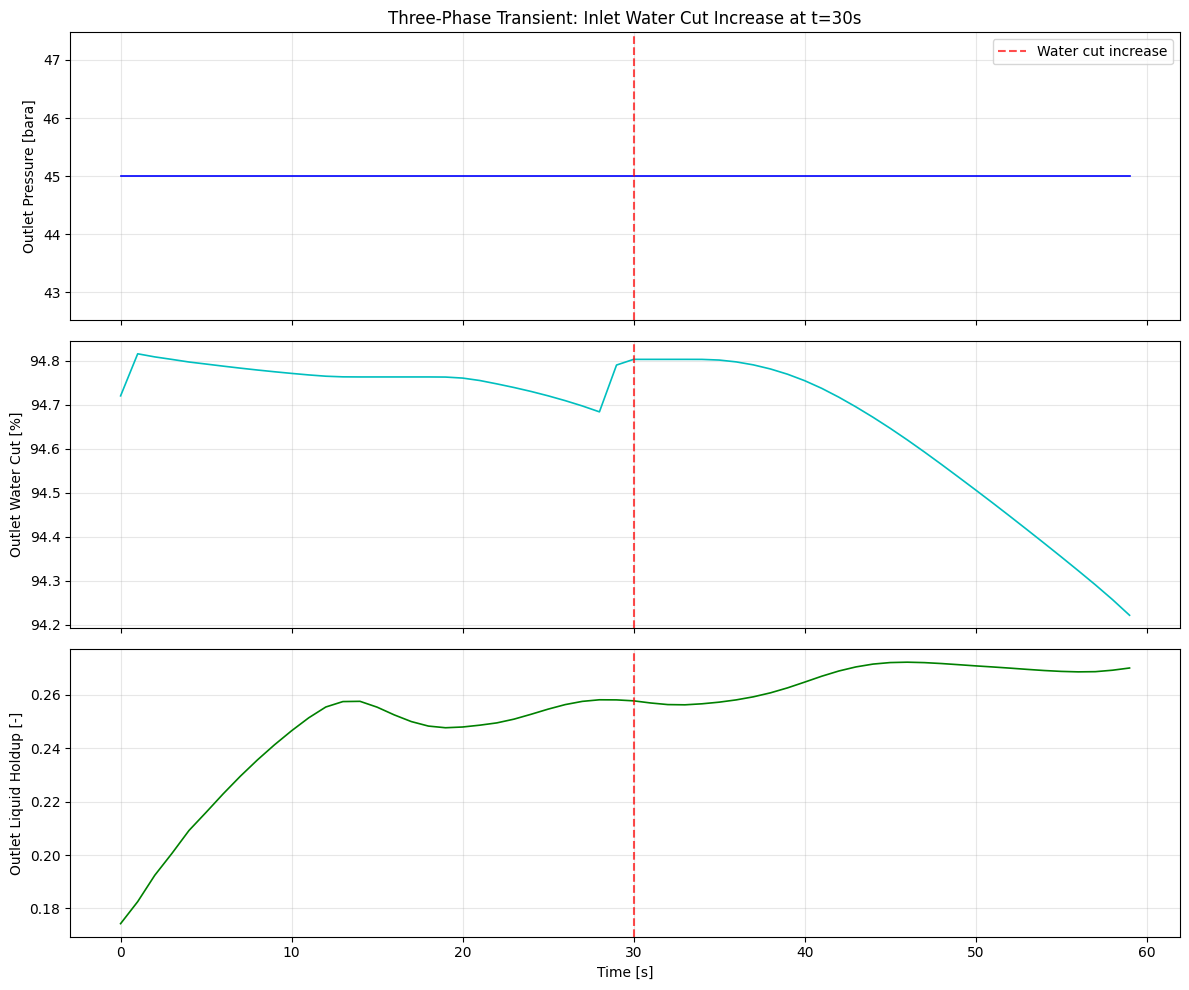

Plot complete.


In [15]:
# Plot three-phase transient response to water cut change
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(wc_times, wc_outlet_p, 'b-', linewidth=1.2)
axes[0].axvline(x=30, color='red', linestyle='--', alpha=0.7, label='Water cut increase')
axes[0].set_ylabel('Outlet Pressure [bara]')
axes[0].set_title('Three-Phase Transient: Inlet Water Cut Increase at t=30s')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(wc_times, wc_outlet_wc, 'c-', linewidth=1.2)
axes[1].axvline(x=30, color='red', linestyle='--', alpha=0.7)
axes[1].set_ylabel('Outlet Water Cut [%]')
axes[1].grid(True, alpha=0.3)

axes[2].plot(wc_times, wc_outlet_holdup, 'g-', linewidth=1.2)
axes[2].axvline(x=30, color='red', linestyle='--', alpha=0.7)
axes[2].set_ylabel('Outlet Liquid Holdup [-]')
axes[2].set_xlabel('Time [s]')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('three_phase_transient_wc_change.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot complete.")

---
## 8. Large-Scale Flowline + S-Riser: Non-Uniform Mesh

A classic flow assurance scenario: a **5 km subsea flowline** at 200 m water depth connects to an **S-shaped riser** rising to a topside platform.

### Geometry
```
Platform (0 m)
    │   ← Riser top (vertical, 200m)
    │
    │   ← Upper catenary
    │
    └─── Riser base (dip to -210 m)
         │
─────────┘  ← Flowline (5 km, slight downslope from -195 m to -200 m)
Wellhead (-195 m)
```

### Non-Uniform Mesh

Commercial simulators (OLGA, LedaFlow) use **static non-uniform meshes** to place finer cells
where gradients are steepest — typically at risers, terrain undulations, and wellheads.
NeqSim's `TwoFluidPipe` supports this via two approaches:

| Method | Usage |
|--------|-------|
| `setSectionLengths(double[])` | Manual: provide exact length for each section |
| `generateRefinedMesh(baseSections, refinementFactor)` | Automatic: refines based on elevation gradient |

`generateRefinedMesh` analyses the elevation profile and creates **shorter cells where the gradient
is steepest** (riser sections) and **longer cells where the pipe is flat** (flowline). The
`refinementFactor` controls the ratio between the coarsest and finest cells (clamped to 1.5–10).

**CFL note**: With explicit time integration (RK4), the global timestep is governed by the
*smallest* cell. Finer riser cells → smaller dt → more sub-steps. This improves accuracy at
the cost of speed. Semi-implicit solvers (OLGA-style) avoid this penalty but are not yet
implemented.

### Performance Controls

| Method | Default | Effect |
|--------|---------|--------|
| `generateRefinedMesh(N, factor)` | uniform | Auto-refines mesh based on elevation gradients |
| `setSectionLengths(lengths[])` | uniform | Manual per-section lengths |
| `setEnableAdaptiveTimestepping(True)` | `False` | **OLGA-style adaptive dt**: per-step CFL recompute, instability detect + rollback |
| `setAdaptiveMaxPressure(bar)` | 1000 | Pressure ceiling — rejects and halves dt if exceeded |
| `setThermodynamicUpdateInterval(N)` | 10 | Flash every N sub-steps → reduces expensive TPflash calls |
| `setCflNumber(cfl)` | 0.5 | Higher CFL → larger timesteps (0.1–0.9) |

In [3]:
# === 8. FLOWLINE + S-RISER: Non-Uniform Mesh ===
#
# Use generateRefinedMesh() to automatically create finer cells at the riser
# (steep elevation gradient) and coarser cells in the flat flowline.
# Time integration: RK4 (acoustically stable, no IMEX issues in vertical risers)
# Adaptive timestepping provides rollback safety for gravity-dominated sections.

import time as _time

riser_fluid = SystemSrkEos(273.15 + 60.0, 40.0)
riser_fluid.addComponent("methane", 0.60)
riser_fluid.addComponent("ethane", 0.08)
riser_fluid.addComponent("propane", 0.06)
riser_fluid.addComponent("n-butane", 0.04)
riser_fluid.addComponent("n-pentane", 0.06)
riser_fluid.addComponent("n-heptane", 0.10)
riser_fluid.addComponent("nC10", 0.06)
riser_fluid.setMixingRule("classic")
riser_fluid.setMultiPhaseCheck(True)

riser_feed = Stream("Subsea Feed", riser_fluid)
riser_feed.setFlowRate(30000.0, "kg/hr")
riser_feed.setTemperature(60.0, "C")
riser_feed.setPressure(40.0, "bara")

# --- Build elevation profile ---
n_total_sec = 100
L_flowline = 5000.0   # 5 km
L_riser = 400.0        # 400 m riser (S-shape)
L_total = L_flowline + L_riser

elevation_sr = []

# Flowline: gentle downslope from -195 m to -200 m  (70% of total length)
n_elev_fl = 70
for i in range(n_elev_fl):
    frac_fl = float(i) / (n_elev_fl - 1)
    elev = -195.0 - 5.0 * frac_fl
    elevation_sr.append(elev)

# S-riser: dip to -210 m, then catenary up to 0 m  (30% of total length)
n_elev_r = 30
for i in range(n_elev_r):
    frac_r = float(i) / (n_elev_r - 1)
    if frac_r < 0.10:
        elev = -200.0 - 10.0 * (frac_r / 0.10)
    elif frac_r < 0.20:
        local_frac = (frac_r - 0.10) / 0.10
        elev = -210.0 + 10.0 * local_frac
    else:
        local_frac = (frac_r - 0.20) / 0.80
        elev = -200.0 + 200.0 * local_frac
    elevation_sr.append(elev)

# Create pipe with non-uniform mesh
riser_pipe = TwoFluidPipe("Flowline-Riser", riser_feed)
riser_pipe.setLength(L_total)
riser_pipe.setDiameter(0.2032)        # 8 inch
riser_pipe.setOutletPressure(20.0, "bara")
riser_pipe.setRoughness(5e-5)

# Set elevation profile FIRST, then generate refined mesh
riser_pipe.setElevationProfile(elevation_sr)
riser_pipe.generateRefinedMesh(n_total_sec, 4.0)  # 4x refinement at riser

# Inspect resulting mesh
sec_lengths = list(riser_pipe.getSectionLengths())
n_actual = len(sec_lengths)
dx_min = min(sec_lengths)
dx_max = max(sec_lengths)
dx_uniform = L_total / n_total_sec

print(f"=== Non-Uniform Mesh ({n_actual} sections) ===")
print(f"  Uniform dx would be: {dx_uniform:.1f} m")
print(f"  Actual dx range: [{dx_min:.1f}, {dx_max:.1f}] m  (ratio {dx_max/dx_min:.1f}x)")
print(f"  First 5 (flowline): {['%.1f' % s for s in sec_lengths[:5]]} m")
print(f"  Last 5 (riser top): {['%.1f' % s for s in sec_lengths[-5:]]} m")
print(f"  Around riser base:  {['%.1f' % s for s in sec_lengths[68:73]]} m")

# === SETTINGS ===
riser_pipe.setThermodynamicUpdateInterval(15)
riser_pipe.setCflNumber(0.5)
riser_pipe.setEnableAdaptiveTimestepping(True)
riser_pipe.setAdaptiveMaxPressure(200.0)

print(f"\nConfiguration: {n_actual} sections (non-uniform), RK4 (acoustic CFL), CFL=0.5")
print(f"  Flash every 15 sub-steps, adaptive dt enabled")
print(f"  CFL governed by dx_min = {dx_min:.1f} m (riser sections)")

# --- Run steady-state ---
t0_ss = _time.time()
riser_proc = ProcessSystem()
riser_proc.add(riser_feed)
riser_proc.add(riser_pipe)
riser_proc.run()
t_ss = _time.time() - t0_ss
print(f"\nSteady-state completed in {t_ss:.1f}s wall-clock")

# Extract steady-state profiles
pos_sr = np.array(list(riser_pipe.getPositionProfile())) / 1000
P_sr = np.array(list(riser_pipe.getPressureProfile())) / 1e5
HL_sr = np.array(list(riser_pipe.getLiquidHoldupProfile()))
vG_sr = np.array(list(riser_pipe.getGasVelocityProfile()))
vL_sr = np.array(list(riser_pipe.getLiquidVelocityProfile()))
elev_sr_arr = np.array(elevation_sr[:len(pos_sr)])

dp_sr = P_sr[0] - P_sr[-1]
n_fl = n_elev_fl  # approx boundary index
print(f"\n=== Flowline + S-Riser Steady-State ===")
print(f"Total length: {L_total/1000:.1f} km ({L_flowline/1000:.0f} km flowline + {L_riser:.0f} m riser)")
print(f"Inlet P = {P_sr[0]:.1f} bar, Outlet P = {P_sr[-1]:.1f} bar, dP = {dp_sr:.1f} bar")
print(f"Flowline avg holdup = {np.mean(HL_sr[:n_fl]):.3f}")
print(f"Riser avg holdup    = {np.mean(HL_sr[n_fl:]):.3f}")

i_base = np.argmin(elev_sr_arr)
print(f"\nRiser base at x = {pos_sr[i_base]:.2f} km, elev = {elev_sr_arr[i_base]:.0f} m")
print(f"Riser base holdup = {HL_sr[i_base]:.3f}")
print(f"Riser base pressure = {P_sr[i_base]:.1f} bar")
print(f"Riser top holdup = {HL_sr[-1]:.3f}")
print(f"\nFlow analysis:")
print(riser_pipe.getFlowAnalysisSummary())

# --- Run transient with progress tracking ---
sim_seconds = 120.0   # 2 minutes
dt = 0.5
n_transient = int(sim_seconds / dt)
print(f"\n=== Transient: {sim_seconds:.0f}s, dt={dt}s, {n_transient} steps ===")
print(f"  Adaptive timestepping: {riser_pipe.isAdaptiveTimesteppingEnabled()}")

sr_times = []
sr_inlet_p = []
sr_outlet_p = []
sr_outlet_holdup = []
sr_base_holdup = []
dt_factor_log = []

run_id_sr = UUID.randomUUID()
t0_tr = _time.time()
last_report = 0.0

for step in range(n_transient):
    t = step * dt
    riser_pipe.runTransient(dt, run_id_sr)

    sr_times.append(t)
    p_prof = list(riser_pipe.getPressureProfile())
    h_prof = list(riser_pipe.getLiquidHoldupProfile())

    sr_inlet_p.append(p_prof[0] / 1e5)
    sr_outlet_p.append(p_prof[-1] / 1e5)
    sr_outlet_holdup.append(h_prof[-1])
    sr_base_holdup.append(h_prof[min(i_base, len(h_prof)-1)])
    dt_factor_log.append(float(riser_pipe.getAdaptiveDtFactor()))

    # Progress report every 15s of simulated time
    if t - last_report >= 15.0 or step == n_transient - 1:
        elapsed = _time.time() - t0_tr
        pct = (step + 1) / n_transient * 100
        rate = (t + dt) / elapsed if elapsed > 0 else 0
        eta = (sim_seconds - t - dt) / rate if rate > 0 else 0
        dtf = dt_factor_log[-1]
        print(f"  t={t+dt:6.1f}s / {sim_seconds:.0f}s ({pct:5.1f}%) | "
              f"wall={elapsed:5.1f}s | sim/wall={rate:.1f}x | ETA={eta:.0f}s | "
              f"dtFactor={dtf:.4f} | "
              f"base HL={sr_base_holdup[-1]:.3f} | P_in={sr_inlet_p[-1]:.1f}")
        last_report = t

t_tr = _time.time() - t0_tr
print(f"\nTransient completed in {t_tr:.1f}s wall-clock ({sim_seconds/t_tr:.1f}x realtime)")

# Adaptive dt summary
min_dtf = min(dt_factor_log) if dt_factor_log else 1.0
max_dtf = max(dt_factor_log) if dt_factor_log else 1.0
n_reduced = sum(1 for f in dt_factor_log if f < 0.95)
print(f"\nAdaptive dt summary:")
print(f"  dt factor range: [{min_dtf:.4f}, {max_dtf:.4f}]")
print(f"  Steps with reduced dt: {n_reduced}/{len(dt_factor_log)} ({100*n_reduced/max(len(dt_factor_log),1):.1f}%)")

# Final profiles
pos_sr_f = np.array(list(riser_pipe.getPositionProfile())) / 1000
P_sr_f = np.array(list(riser_pipe.getPressureProfile())) / 1e5
HL_sr_f = np.array(list(riser_pipe.getLiquidHoldupProfile()))
vG_sr_f = np.array(list(riser_pipe.getGasVelocityProfile()))

print(f"\nFinal state:")
print(f"  Inlet P = {P_sr_f[0]:.1f} bar, Outlet P = {P_sr_f[-1]:.1f} bar")
print(f"  Flowline avg holdup = {np.mean(HL_sr_f[:n_fl]):.3f}")
print(f"  Riser avg holdup    = {np.mean(HL_sr_f[n_fl:]):.3f}")
print(f"  Riser base holdup   = {HL_sr_f[min(i_base, len(HL_sr_f)-1)]:.3f}")
print(f"  Riser top holdup    = {HL_sr_f[-1]:.3f}")

=== Non-Uniform Mesh (100 sections) ===
  Uniform dx would be: 54.0 m
  Actual dx range: [17.4, 68.5] m  (ratio 3.9x)
  First 5 (flowline): ['67.8', '67.8', '67.8', '67.8', '67.8'] m
  Last 5 (riser top): ['17.4', '17.4', '17.4', '17.4', '17.4'] m
  Around riser base:  ['67.8', '68.5', '47.0', '33.6', '33.0'] m

Configuration: 100 sections (non-uniform), RK4 (acoustic CFL), CFL=0.5
  Flash every 15 sub-steps, adaptive dt enabled
  CFL governed by dx_min = 17.4 m (riser sections)

Steady-state completed in 2.2s wall-clock

=== Flowline + S-Riser Steady-State ===
Total length: 5.4 km (5 km flowline + 400 m riser)
Inlet P = 40.0 bar, Outlet P = 29.7 bar, dP = 10.3 bar
Flowline avg holdup = 0.269
Riser avg holdup    = 0.203

Riser base at x = 4.89 km, elev = -210 m
Riser base holdup = 0.228
Riser base pressure = 38.5 bar
Riser top holdup = 0.181

Flow analysis:
=== Two-Phase Flow Analysis (Mid-Pipe) ===
Flow regime: STRATIFIED_SMOOTH

--- Velocities ---
Superficial gas velocity (v_SG): 2.8

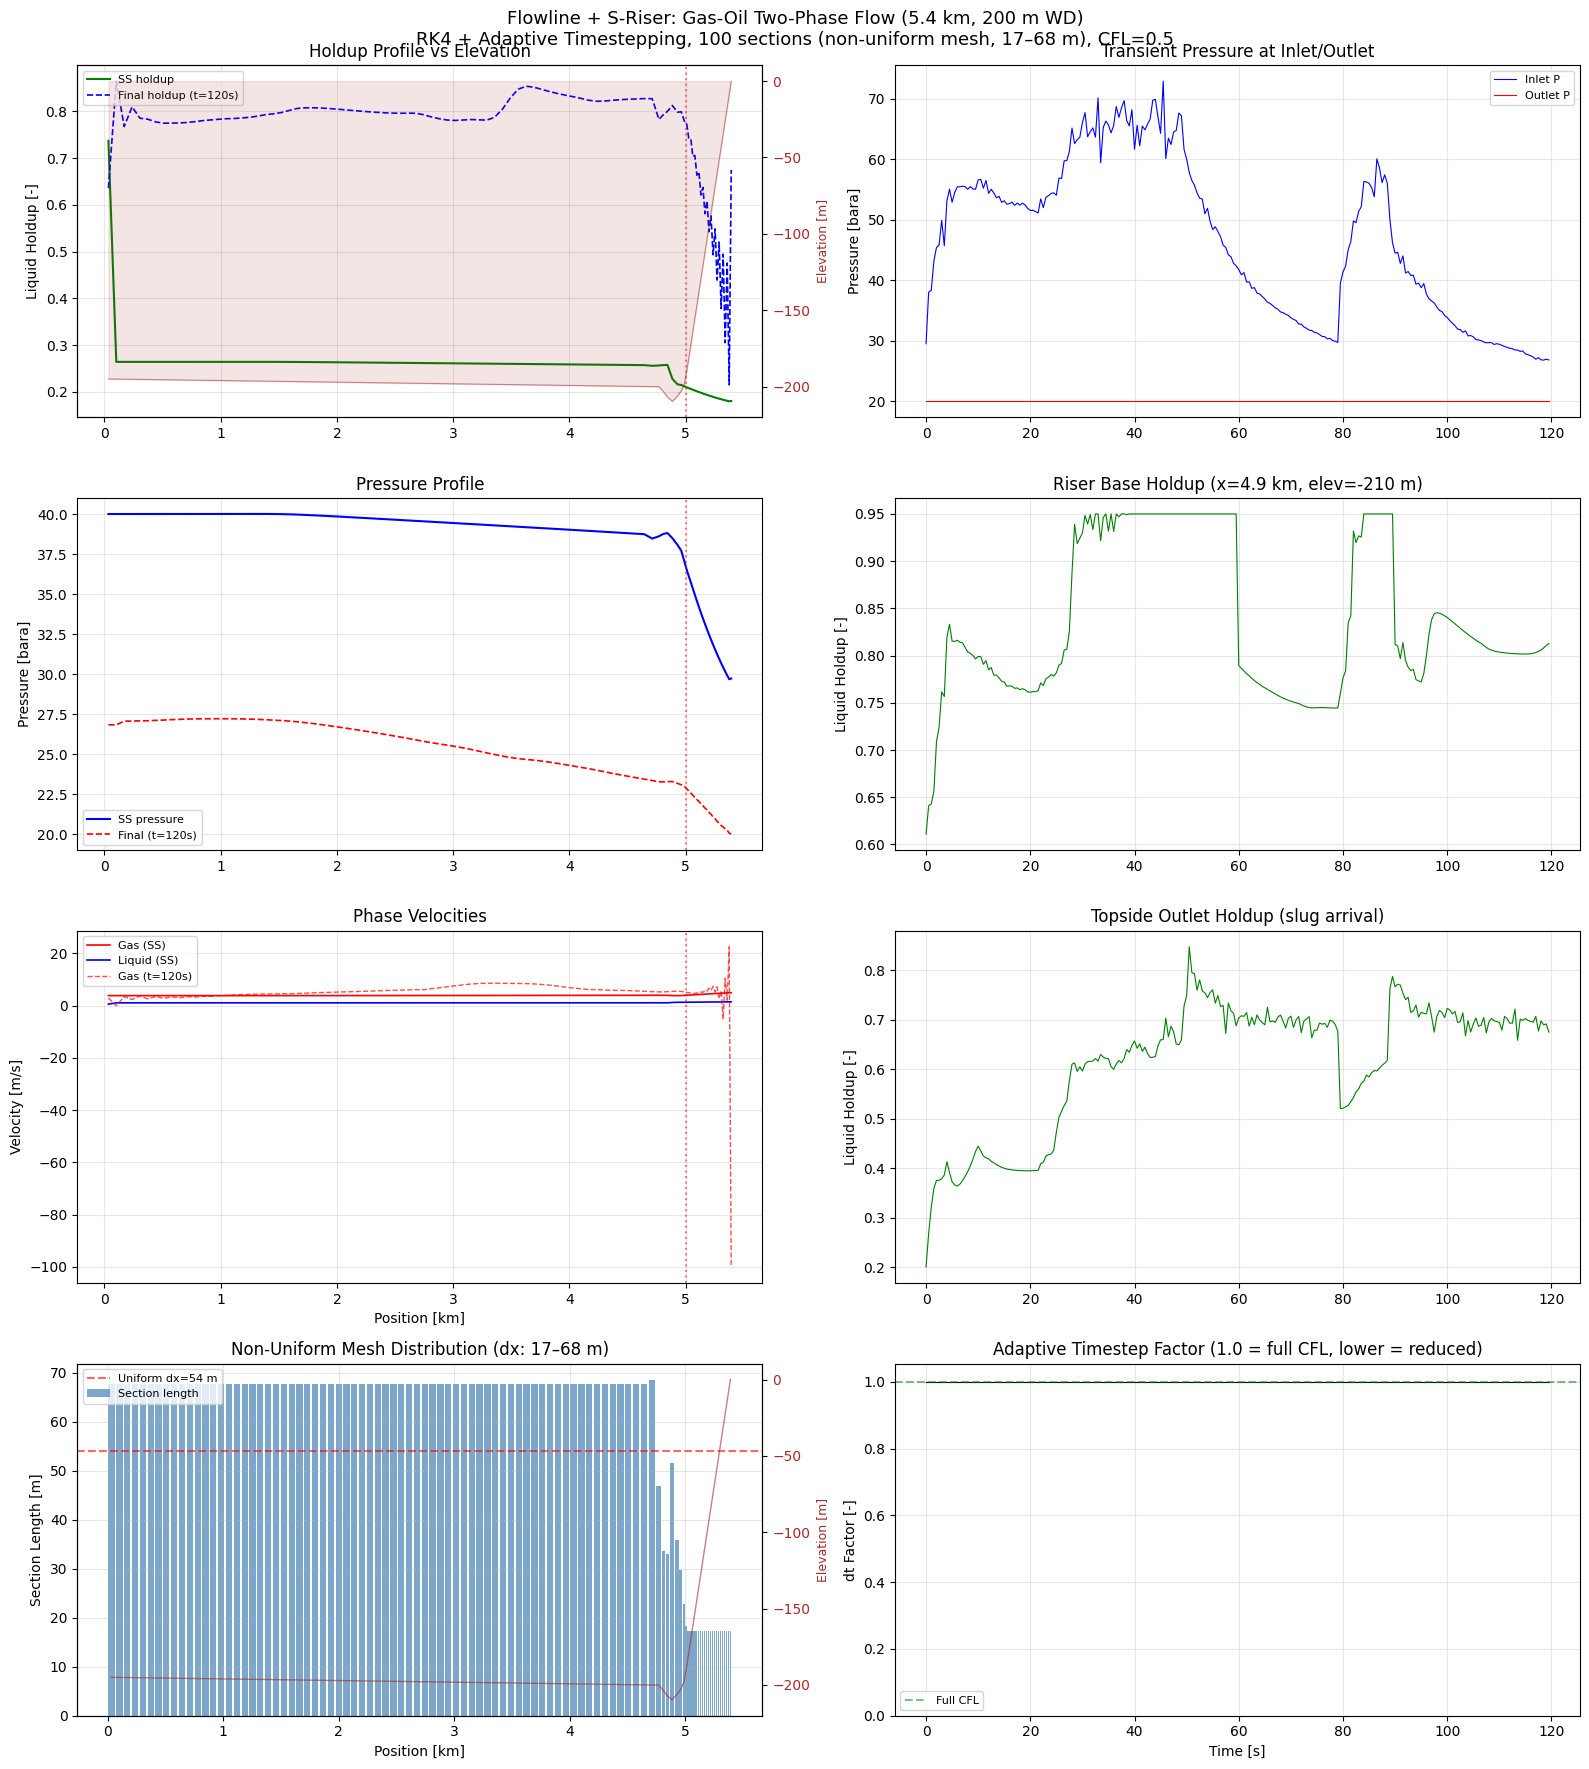


=== Performance Summary ===
  Sections: 100 (non-uniform mesh, dx: 17–68 m)
  Refinement: 4x at riser (steep elevation gradient)
  Time integration: RK4 + adaptive timestepping
  CFL number: 0.5, governed by dx_min = 17 m
  Flash interval: every 15 sub-steps
  Steady-state: 2.2s wall-clock
  Transient (120s sim): 13.9s wall-clock (8.7x realtime)
  Adaptive dt factor: min=1.0000, max=1.0000

=== Physical Interpretation ===
  Flowline: stratified flow, avg holdup = 0.801
  Riser base: liquid accumulation zone, holdup = 0.813
  Riser upleg: holdup decreases with height as gas expands
  Topside: outlet holdup = 0.675

  Hydrostatic pressure (riser, liquid contribution) ~ 8.6 bar
  Total dP = 6.8 bar (friction + hydrostatic + acceleration)


In [4]:
# === Plot Flowline + S-Riser Results ===
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
fig.suptitle(f'Flowline + S-Riser: Gas-Oil Two-Phase Flow (5.4 km, 200 m WD)\n'
             f'RK4 + Adaptive Timestepping, {n_actual} sections (non-uniform mesh, {dx_min:.0f}–{dx_max:.0f} m), CFL=0.5',
             fontsize=13)

# --- Column 1: Steady-state profiles along pipe ---
ax_elev = axes[0, 0].twinx()
axes[0, 0].plot(pos_sr, HL_sr, 'g-', linewidth=1.5, label='SS holdup', zorder=3)
axes[0, 0].plot(pos_sr_f, HL_sr_f, 'b--', linewidth=1.2, label=f'Final holdup (t={sim_seconds:.0f}s)', zorder=3)
ax_elev.fill_between(pos_sr, elev_sr_arr, alpha=0.12, color='brown')
ax_elev.plot(pos_sr, elev_sr_arr, 'brown', linewidth=0.8, alpha=0.5)
ax_elev.set_ylabel('Elevation [m]', color='brown', fontsize=9)
ax_elev.tick_params(axis='y', labelcolor='brown')
axes[0, 0].set_ylabel('Liquid Holdup [-]')
axes[0, 0].set_title('Holdup Profile vs Elevation')
axes[0, 0].legend(loc='upper left', fontsize=8)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(x=L_flowline/1000, color='red', linestyle=':', alpha=0.5)

axes[1, 0].plot(pos_sr, P_sr, 'b-', linewidth=1.5, label='SS pressure')
axes[1, 0].plot(pos_sr_f, P_sr_f, 'r--', linewidth=1.2, label=f'Final (t={sim_seconds:.0f}s)')
axes[1, 0].set_ylabel('Pressure [bara]')
axes[1, 0].set_title('Pressure Profile')
axes[1, 0].axvline(x=L_flowline/1000, color='red', linestyle=':', alpha=0.5)
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

axes[2, 0].plot(pos_sr, vG_sr, 'r-', linewidth=1.2, label='Gas (SS)')
axes[2, 0].plot(pos_sr, vL_sr, 'b-', linewidth=1.2, label='Liquid (SS)')
axes[2, 0].plot(pos_sr_f, vG_sr_f, 'r--', linewidth=1.0, alpha=0.7, label=f'Gas (t={sim_seconds:.0f}s)')
axes[2, 0].set_xlabel('Position [km]')
axes[2, 0].set_ylabel('Velocity [m/s]')
axes[2, 0].set_title('Phase Velocities')
axes[2, 0].axvline(x=L_flowline/1000, color='red', linestyle=':', alpha=0.5)
axes[2, 0].legend(fontsize=8)
axes[2, 0].grid(True, alpha=0.3)

# Mesh distribution + Elevation
ax_elev2 = axes[3, 0].twinx()
cum_pos = [0.0]
for sl in sec_lengths:
    cum_pos.append(cum_pos[-1] + sl)
mid_pos = [(cum_pos[i] + cum_pos[i+1]) / 2.0 / 1000 for i in range(len(sec_lengths))]
axes[3, 0].bar(mid_pos, sec_lengths, width=[s/1000*0.8 for s in sec_lengths],
               color='steelblue', alpha=0.7, label='Section length')
axes[3, 0].axhline(y=dx_uniform, color='red', linestyle='--', alpha=0.6, label=f'Uniform dx={dx_uniform:.0f} m')
axes[3, 0].set_xlabel('Position [km]')
axes[3, 0].set_ylabel('Section Length [m]')
axes[3, 0].set_title(f'Non-Uniform Mesh Distribution (dx: {dx_min:.0f}–{dx_max:.0f} m)')
axes[3, 0].legend(loc='upper left', fontsize=8)
axes[3, 0].grid(True, alpha=0.3)
ax_elev2.plot(pos_sr, elev_sr_arr, 'brown', linewidth=1.0, alpha=0.6)
ax_elev2.set_ylabel('Elevation [m]', color='brown', fontsize=9)
ax_elev2.tick_params(axis='y', labelcolor='brown')

# --- Column 2: Transient dynamics ---
axes[0, 1].plot(sr_times, sr_inlet_p, 'b-', linewidth=0.8, label='Inlet P')
axes[0, 1].plot(sr_times, sr_outlet_p, 'r-', linewidth=0.8, label='Outlet P')
axes[0, 1].set_ylabel('Pressure [bara]')
axes[0, 1].set_title('Transient Pressure at Inlet/Outlet')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 1].plot(sr_times, sr_base_holdup, 'g-', linewidth=0.8)
axes[1, 1].set_ylabel('Liquid Holdup [-]')
axes[1, 1].set_title(f'Riser Base Holdup (x={pos_sr[i_base]:.1f} km, elev={elev_sr_arr[i_base]:.0f} m)')
axes[1, 1].grid(True, alpha=0.3)

axes[2, 1].plot(sr_times, sr_outlet_holdup, 'g-', linewidth=0.8)
axes[2, 1].set_ylabel('Liquid Holdup [-]')
axes[2, 1].set_title('Topside Outlet Holdup (slug arrival)')
axes[2, 1].grid(True, alpha=0.3)

# Adaptive dt factor trace
axes[3, 1].plot(sr_times, dt_factor_log, 'k-', linewidth=0.8)
axes[3, 1].set_xlabel('Time [s]')
axes[3, 1].set_ylabel('dt Factor [-]')
axes[3, 1].set_title('Adaptive Timestep Factor (1.0 = full CFL, lower = reduced)')
axes[3, 1].set_ylim(bottom=0)
axes[3, 1].grid(True, alpha=0.3)
axes[3, 1].axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='Full CFL')
axes[3, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('flowline_sriser_nonuniform.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print(f"\n=== Performance Summary ===")
print(f"  Sections: {n_actual} (non-uniform mesh, dx: {dx_min:.0f}–{dx_max:.0f} m)")
print(f"  Refinement: 4x at riser (steep elevation gradient)")
print(f"  Time integration: RK4 + adaptive timestepping")
print(f"  CFL number: 0.5, governed by dx_min = {dx_min:.0f} m")
print(f"  Flash interval: every 15 sub-steps")
print(f"  Steady-state: {t_ss:.1f}s wall-clock")
print(f"  Transient ({sim_seconds:.0f}s sim): {t_tr:.1f}s wall-clock ({sim_seconds/t_tr:.1f}x realtime)")
print(f"  Adaptive dt factor: min={min_dtf:.4f}, max={max_dtf:.4f}")
print(f"\n=== Physical Interpretation ===")
print(f"  Flowline: stratified flow, avg holdup = {np.mean(HL_sr_f[:n_fl]):.3f}")
print(f"  Riser base: liquid accumulation zone, holdup = {HL_sr_f[min(i_base, len(HL_sr_f)-1)]:.3f}")
print(f"  Riser upleg: holdup decreases with height as gas expands")
print(f"  Topside: outlet holdup = {HL_sr_f[-1]:.3f}")
hydro_p = 200 * 9.81 * np.mean(HL_sr_f[n_fl:]) * 700 / 1e5
print(f"\n  Hydrostatic pressure (riser, liquid contribution) ~ {hydro_p:.1f} bar")
print(f"  Total dP = {P_sr_f[0] - P_sr_f[-1]:.1f} bar (friction + hydrostatic + acceleration)")

---
## Summary

This notebook demonstrated the full capabilities of NeqSim's `TwoFluidPipe` model:

| Section | # Phases | Mode | Key Features |
|---------|----------|------|-------------|
| 1. One-Phase Flow | 1 (gas) | Steady-state | Pressure/temperature profiles, cross-validation with Beggs & Brill |
| 2. Two-Phase Flow | 2 (gas + condensate) | Steady-state | Liquid holdup, velocities, slip ratio, flow regimes |
| 3. Three-Phase Flow | 3 (gas + oil + water) | Steady-state | Water cut tracking, phase holdups, mass balance |
| 4. Boundary Conditions | 2 | Steady-state | STREAM_CONNECTED, CONSTANT_FLOW, CONSTANT_PRESSURE comparison |
| 5. Transient Dynamics | 2 | Transient | Flow ramp-up, shut-in (closeOutlet), reopen (openOutlet) |
| 6. Slug Tracking | 2 | Transient | Lagrangian slug tracking, terrain undulations, slug statistics |
| 7. Three-Phase Transient | 3 | Transient | Inlet composition change (water breakthrough), water cut propagation |
| 8. Flowline + S-Riser | 2 (gas + oil) | SS + Transient | Non-uniform mesh (finer at riser), large-scale subsea geometry, riser-base holdup |

### Key Takeaways

1. **Boundary conditions** control how the pipe interacts with the rest of the flowsheet. Use `STREAM_CONNECTED` for inlet (default) and `CONSTANT_PRESSURE` for outlet.
2. **Transient simulations** require calling `runTransient(dt, uuid)` in a loop. The steady-state solution serves as the initial condition.
3. **Inlet/outlet changes during transient**: Modify feed stream properties (`setFluid`, `setFlowRate`) or use `closeOutlet()`/`openOutlet()` to simulate operational changes.
4. **Slug tracking** is enabled via `setEnableSlugTracking(True)` with terrain undulations promoting slug formation. Use `getSlugStatisticsSummary()` for slug frequency and length data.
5. **Three-phase transient** simulations capture water cut propagation dynamics — important for corrosion management and separator sizing.
6. **Non-uniform mesh**: Use `generateRefinedMesh(N, factor)` to auto-refine based on elevation gradient, or `setSectionLengths(lengths)` for manual control. Finer cells at risers improve accuracy but reduce CFL timestep.

### Further Reading
- [Pipeline Recipes Cookbook](../../docs/cookbook/pipeline-recipes.md) — Quick recipes for common pipeline simulations
- [TwoFluidPipe API Reference](../../docs/cookbook/pipeline-recipes.md#twofluidpipe-complete-api-reference) — Full enumeration and method reference